# Нейронная сеть классификации рукописного текста датасета MNIST

## 1. Импорт библиотек

In [45]:
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
from time import time
from torchvision import datasets, transforms
from torch import nn, optim

numpy: используется для работы с массивами данных X (входы) и y (цели).

torch: для работы с нейронными сетями.

torchvision: для загрузки стандартных датасетов.

matplotlib: для визуализации данных.

time: измерение времени выполнения.

## 2. Функция для нормализации датасета

In [46]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

Данные преобразуются с помощью:

ToTensor: конвертирует изображения в тензоры.

Normalize: нормализует данные так, чтобы значения были в диапазоне [-1, 1].

## 3. Загрузка тренировочного и тестового датасета MNIST

In [47]:
# тренировочная выборка
trainset = datasets.MNIST('PATH_TO_STORE_TRAINSET', download=True, train=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
# тестовая выборка
valset = datasets.MNIST('PATH_TO_STORE_TESTSET', download=True, train=False, transform=transform)
valloader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=True)

datasets.MNIST: загружает MNIST.

DataLoader: создаёт батчи для тренировочных (trainloader) и тестовых (valloader) данных.

## 4. Размер тензора с выборкой изображений и размер тензора с выборкой меток

In [48]:
dataiter = iter(trainloader)
images, labels = next(dataiter)
print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


images.shape: размерность изображений. (Например, [64, 1, 28, 28] для батча из 64 чёрно-белых изображений 28x28 пикселей).

labels.shape: размерность меток (длина равна размеру батча).

## 5. часть выборки

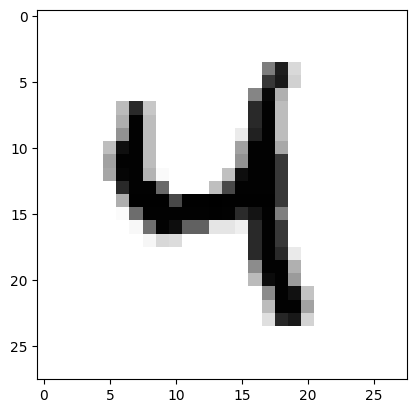

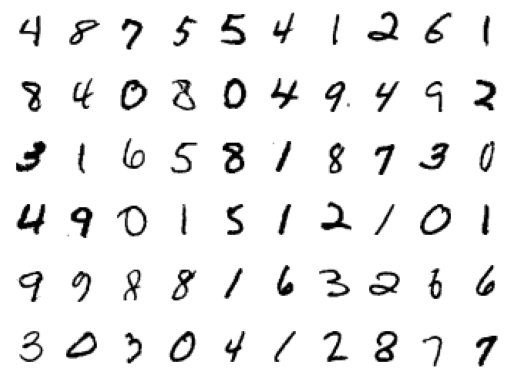

In [49]:
# сначала одно изоборажение
plt.imshow(images[0].numpy().squeeze(), cmap='gray_r')
# потом несколько
figure = plt.figure()
num_of_images = 60
for index in range(1, num_of_images+1):
    plt.subplot(6, 10, index)
    plt.axis('off')
    plt.imshow(images[index].numpy().squeeze(), cmap='gray_r')

images[0].numpy().squeeze(): убирает лишние оси, чтобы получить массив 2D.

## 6. Определение модели

In [50]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(28 * 28, 256)  # Первый скрытый слой
        self.hidden2 = nn.Linear(256, 128)     # Второй скрытый слой
        self.hidden3 = nn.Linear(128, 64)      # Третий скрытый слой
        self.output = nn.Linear(64, 10)        # Выходной слой
        
        self.relu = nn.ReLU()
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = x.view(x.shape[0], -1)  # Разворачиваем вектор
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))
        x = self.relu(self.hidden3(x))
        x = self.softmax(self.output(x))
        return x

Слои:
Скрытые: 
784→256, 
256→128, 
128→64.
Выходной: 
64→10.

Активации:
ReLU: нелинейность.
LogSoftmax: выходные вероятности.

## 7. Обучение модели

In [51]:
# Создаём модель
model = Classifier()

# Определяем функцию потерь и оптимизатор
criterion = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
time0 = time()
# Обучение модели
epochs = 5
for e in range(epochs):
    running_loss = 0
    for images, labels in trainloader:
        optimizer.zero_grad()          # Обнуление градиентов
        output = model(images)         # Прямой проход
        loss = criterion(output, labels)  # Вычисление ошибки
        loss.backward()                # Обратный проход
        optimizer.step()               # Обновление весов
        running_loss += loss.item()
    print(f"Эпоха {e+1}/{epochs} - Потеря: {running_loss / len(trainloader):0.3}")
    print(f"Время тренировки {(time()-time0)/60:0.3} минут\n")


Эпоха 1/5 - Потеря: 0.369
Время тренировки 0.523 минут

Эпоха 2/5 - Потеря: 0.158
Время тренировки 1.04 минут

Эпоха 3/5 - Потеря: 0.118
Время тренировки 1.59 минут

Эпоха 4/5 - Потеря: 0.0967
Время тренировки 2.11 минут

Эпоха 5/5 - Потеря: 0.0843
Время тренировки 2.52 минут



Каждая эпоха проходит весь датасет.

Градиенты обнуляются перед каждым батчем (optimizer.zero_grad).

Считается ошибка (criterion), затем обновляются веса (optimizer.step).

## 8. Пример предсказания

На картинке циферка  9


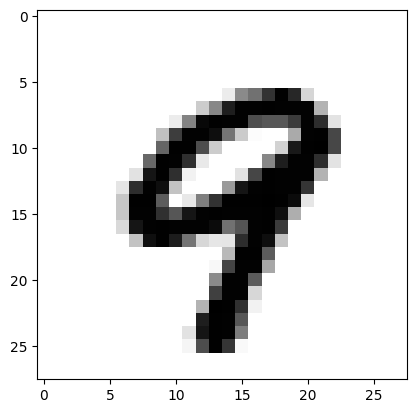

In [52]:
# сначала одно изоборажение
images, labels = next(iter(valloader))

img = images[0].view(1, 784)
with torch.no_grad():
    logps = model(img)

ps = torch.exp(logps)
probab = list(ps.numpy()[0])

plt.imshow(images[0].numpy().squeeze(), cmap='gray_r')

print("На картинке циферка ", probab.index(max(probab)))

probab.index(max(probab)): определяет класс с максимальной вероятностью.

## 9. Оценка точности

In [53]:
# Оценка точности на тестовом наборе
correct_count, all_count = 0, 0
with torch.no_grad():
    for images, labels in valloader:
        preds = model(images)
        correct_count += (preds.argmax(1) == labels).sum().item()
        all_count += labels.size(0)
print(f"Прогнали через сеть {all_count} изображений")
print(f"Точность модели на тестовых данных: {correct_count / all_count * 100:.2f}%")

Прогнали через сеть 10000 изображений
Точность модели на тестовых данных: 96.98%


Сравнивает предсказания модели (preds.argmax(1)) с истинными метками (labels).

## 10. Визуализация предсказаний

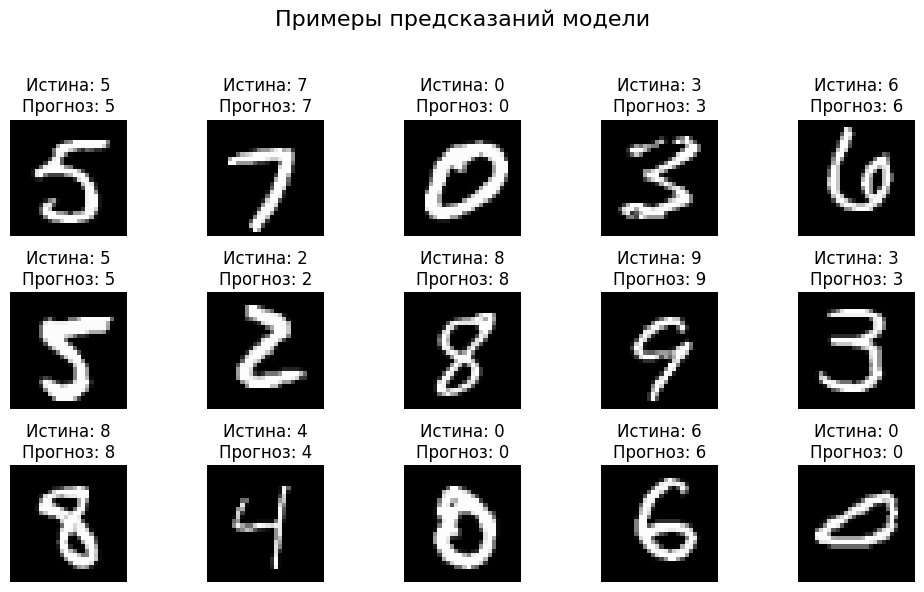

In [54]:
# Визуализация предсказаний
fig, axes = plt.subplots(3, 5, figsize=(10, 6))
fig.suptitle('Примеры предсказаний модели', fontsize=16)

# Извлекаем одну партию данных из тестового набора
dataiter = iter(valloader)
images, labels = next(dataiter)

# Получаем предсказания для текущей партии
with torch.no_grad():
    preds = model(images)

# Визуализация
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].numpy().squeeze(), cmap='gray')
    ax.set_title(f"Истина: {labels[i].item()}\nПрогноз: {preds.argmax(1)[i].item()}")
    ax.axis('off')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
